In [5]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
import poppy
import skimage
from skimage.registration import phase_cross_correlation
import copy
from importlib import reload
from IPython.display import clear_output, display
import multiprocessing
import subprocess
import glob
from pathlib import Path
import os
cwd = Path(os.getcwd())

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle

import magpyx
from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, rt_utils, coro_utils

import fsm_utils
import cam_utils

v_bias = np.array([[50,50,50]]).T
zero = np.array([[0,0,0]]).T

wavelength = 633e-9
fl = 500e-3
fsm_pupil_diam = 6.7e-3
rad_per_lamD = wavelength/fsm_pupil_diam
print(rad_per_lamD)
as_per_lamD = (wavelength/fsm_pupil_diam*u.radian).to_value(u.arcsec)
print(as_per_lamD)

pxscl_lamD = 3.45e-6 / (fl * wavelength/fsm_pupil_diam)
print(pxscl_lamD)

INFO:purepyindi2.transports:Opening localhost:7624...


9.44776119402985e-05
19.48740632155403
0.07303317535545024


INFO:purepyindi2.transports:Connected to localhost:7624


In [2]:
reload(cam_utils)
cam = cam_utils.CAM('camfsm')


In [14]:
npsf = 64
npsf = 256//2
cam.set_roi(970, 635, npsf, client0)

cam.set_exptime(0.0001, client0)

In [3]:
cam.set_exptime(0.0001, client0)

In [ ]:
cam = cam_utils.CAM('camfsm')

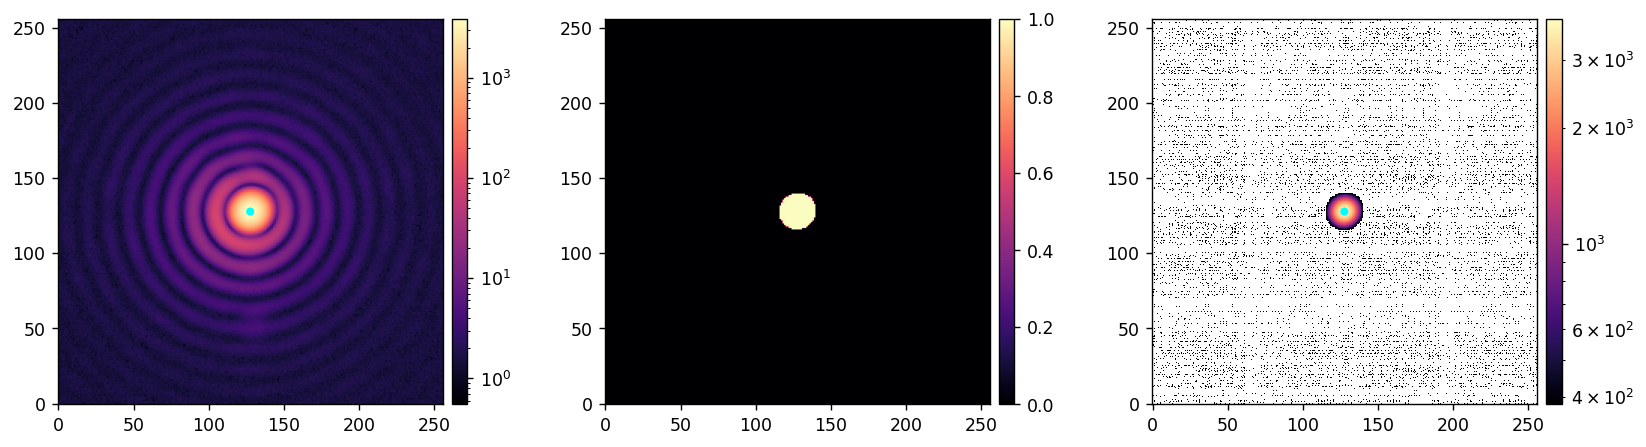

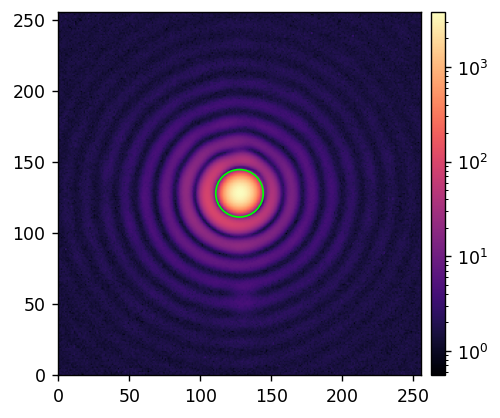

In [6]:
reload(utils)

cam.Nframes = 200
im = cam.snap()

cen = utils.centroid(
    im,
    thresh=0.1*im.max(),
)
utils.imshow(
    [im], 
    norms=[LogNorm()],
    all_patches=[[Circle(cen, 1.22/pxscl_lamD, fill=False, color='lime')]],
)

# Setup FSM Interface

In [8]:
reload(fsm_utils)
fsm_utils.power_fsm('On', client0)

In [16]:
reload(fsm_utils)
fsm_utils.power_fsm('Off', client0)

In [9]:
fsm_stream0 = ImageStream('dm00disp00')
fsm_stream1 = ImageStream('dm00disp01')
fsm_stream1.shape

(1, 3)

In [13]:
fsm_stream0.write(v_bias)

In [15]:
fsm_stream0.write(zero)

In [ ]:
fsm_stream1.write(zero)

In [ ]:
fsm_stream1.write(np.array([[-1, 1, 1]]).T)

In [ ]:
fsm_stream1.write(np.random.randn(3,1))

# Setup and record the modulation

In [17]:
# Define a step command
amp = 1*u.arcsec

volt_commands = np.zeros((2, 3, 1))
volt_commands[1] = fsm_utils.get_fsm_volts(tip=amp, tilt=0*u.arcsec, dZ=0*u.um)
print(volt_commands)

utils.save_fits('/opt/MagAOX/calib/dm/fsm/fsm_square_cube.fits', volt_commands)

[[[ 0.        ]
  [ 0.        ]
  [ 0.        ]]

 [[ 0.16794439]
  [-0.08397219]
  [-0.08397219]]]
Saved data to:  /opt/MagAOX/calib/dm/fsm/fsm_square_cube.fits


In [22]:
freq = 250

fsm_utils.set_fsm_mod_amp(2, client0, process_name='fsmSquareMod')
fsm_utils.set_fsm_mod_rate(freq, client0, process_name='fsmSquareMod')


In [20]:
fsm_utils.start_fsm_mod(client0, process_name='fsmSquareMod')

In [4]:
fsm_utils.stop_fsm_mod(client0, process_name='fsmSquareMod')

In [23]:
reload(fsm_utils)

t_meas = 1
amp = 1*u.arcsec

exp_time = client0[f'campupil.exptime.current']
fps = client0[f'campupil.fps.current']
data = {
    'EXPTIME':exp_time,
    'FPS':fps, 
    'T_TOTAL':t_meas,
    'AMP':amp,
    'FREQ':freq,
}

cam.Nframes = int(np.round(t_meas*fps))
print(cam.Nframes)

fsm_utils.start_fsm_mod(client0, process_name='fsmSquareMod', delay=1)
frames = cam.snap_cube()
fsm_utils.stop_fsm_mod(client0, process_name='fsmSquareMod')

data.update({'IMAGES':frames})



2513


In [40]:
utils.save_pickle(f'data/modulation/{today}_step_mod_{freq:.1f}Hz_{amp.to_value(u.arcsec):.2f}as.pkl', data)

Saved data to:  data/modulation/20250122_step_mod_40.0Hz_0.18as.pkl


# Analyze data

In [45]:
# Load in old data if required 

# data = utils.load_pickle(f'data/modulation/{20241210}_step_mod.pkl')
# data = utils.load_pickle(f'data/modulation/{20241210}_step_mod_3.pkl')

# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_10.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_15.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_20.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_25.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_30.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_35.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_40.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_45.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241212}_step_mod_50.0.pkl')

# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_40.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_50.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_100.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_110.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_120.0.pkl')

# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_100.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_125.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_150.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_175.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20241213}_step_mod_200.0.pkl')

# data = utils.load_pickle(f'data/modulation/{20250108}_step_mod_5.0.pkl')
# data = utils.load_pickle(f'data/modulation/{20250108}_step_mod_10.0.pkl')

# data = utils.load_pickle(f'data/modulation/20250108_step_mod_100.0Hz_0.18as.pkl')
# data = utils.load_pickle(f'data/modulation/20250108_step_mod_200.0Hz_0.18as.pkl')
# data = utils.load_pickle(f'data/modulation/20250108_step_mod_2.0Hz_9.19as.pkl')
# data = utils.load_pickle(f'data/modulation/20250108_step_mod_2.0Hz_-9.19as.pkl')

# data = utils.load_pickle(f'data/modulation/20250122_step_mod_2.0Hz_-9.19as.pkl')

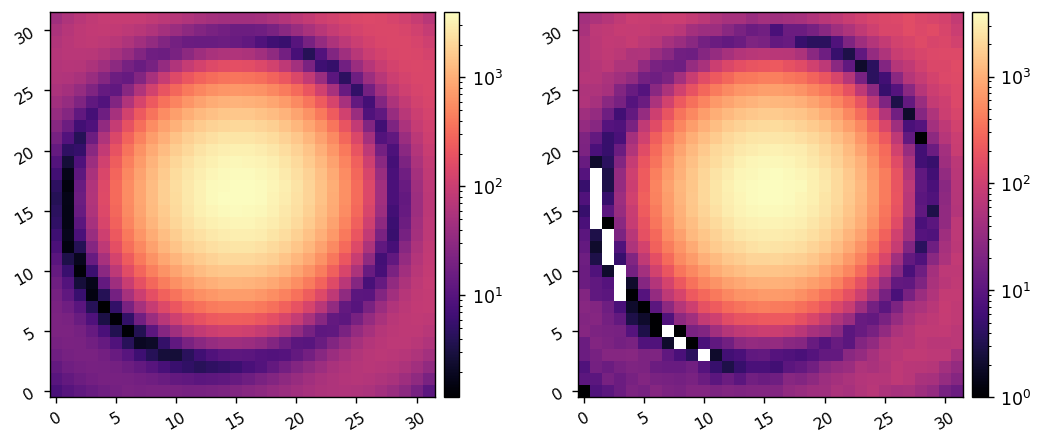

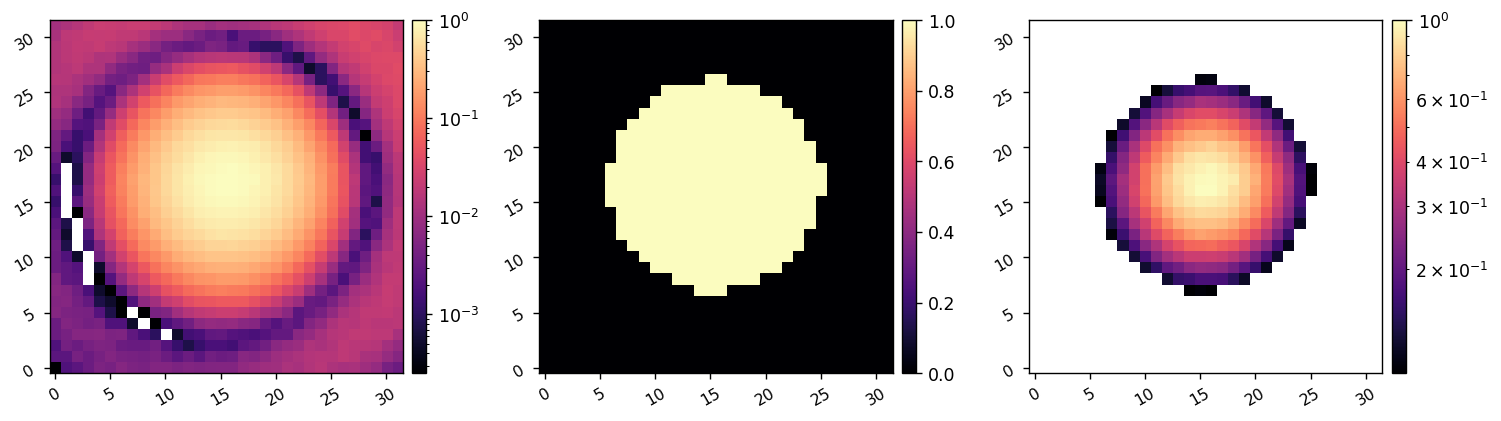

1.0 arcsec


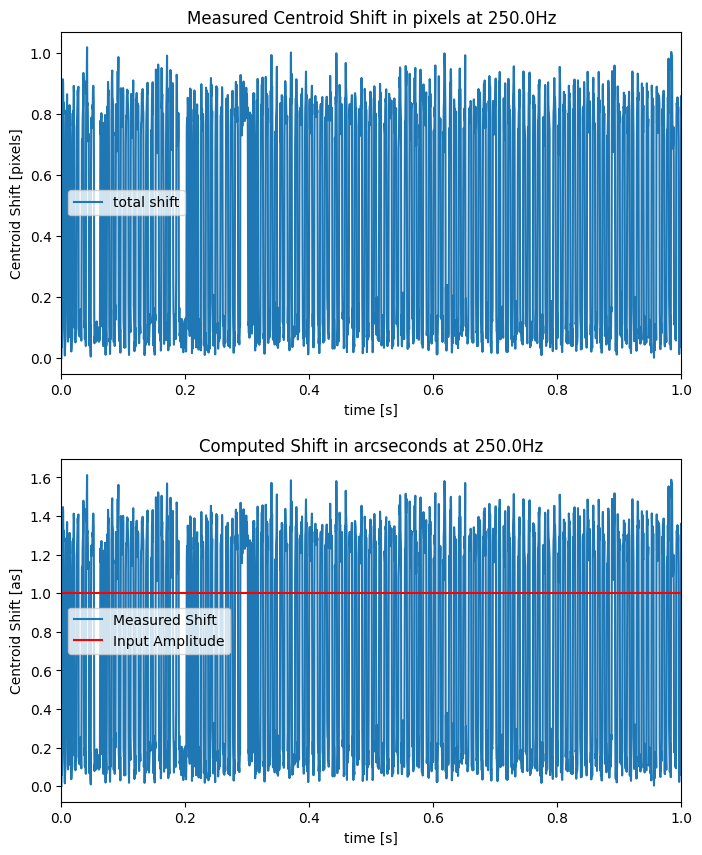

In [24]:
thresh = 0.1

ims = data['IMAGES']
N = ims.shape[0]
fps = data['FPS']
times = np.linspace(0, data['T_TOTAL'], N)
tmax = times.max()

mean_frame = np.mean(ims, axis=0)
imshow2(mean_frame, ims[0], lognorm=True)

shift_pix = []
cen_0 = utils.centroid(ims[0].astype(float), thresh=thresh, plot=True)
for i in range(N):
    cen = utils.centroid(ims[i].astype(float), thresh=thresh, plot=0)
    shift = cen - cen_0
    shift_pix.append(shift)
shift_pix = np.array(shift_pix)

total_shift = np.sqrt( np.sum( np.square(shift_pix), axis=1) )

shift_as = shift_pix * pxscl_lamD * as_per_lamD # pixels * (lamD/pixel) * (as/lamD)
shift_as = np.sqrt( np.sum( np.square(shift_as), axis=1) )

print(data['AMP'])

fig = plt.figure(figsize=(8,10))
plt.subplot(211)
# plt.plot(times, shift_pix[:,0], label='x-coordinate')
# plt.plot(times, shift_pix[:,1], label='y-coordinate')
plt.plot(times, total_shift, label='total shift')
plt.title(f'Measured Centroid Shift in pixels at {data["FREQ"]:.1f}Hz')
plt.ylabel('Centroid Shift [pixels]')
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
plt.legend()

plt.subplot(212)
plt.plot(times, shift_as, label='Measured Shift')
plt.axhline(y=data['AMP'].to_value(u.arcsec), color='r', linestyle='-', label='Input Amplitude')
plt.title(f'Computed Shift in arcseconds at {data["FREQ"]:.1f}Hz')
plt.ylabel('Centroid Shift [as]')
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
plt.legend()

plt.subplots_adjust(hspace=0.25)
plt.show()

253.0


(0.0, 1.0)

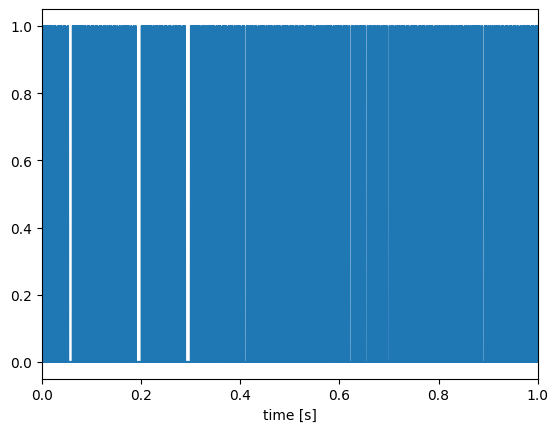

In [25]:
shift_thresh = shift_as.max()/2.2
# shift_thresh = 0.1*u.arcsec

shift_ud = shift_as>shift_thresh
steps = np.abs(shift_ud[1:].astype(float) - shift_ud[:-1].astype(float))
step_count = np.sum(steps)
print(step_count/tmax)

# plt.plot(times, shift_ud,)
# plt.xlabel('time [s]')
# plt.xlim([0,times.max()])
# plt.xlim([0, 1])

plt.plot(times[1:], steps,)
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])


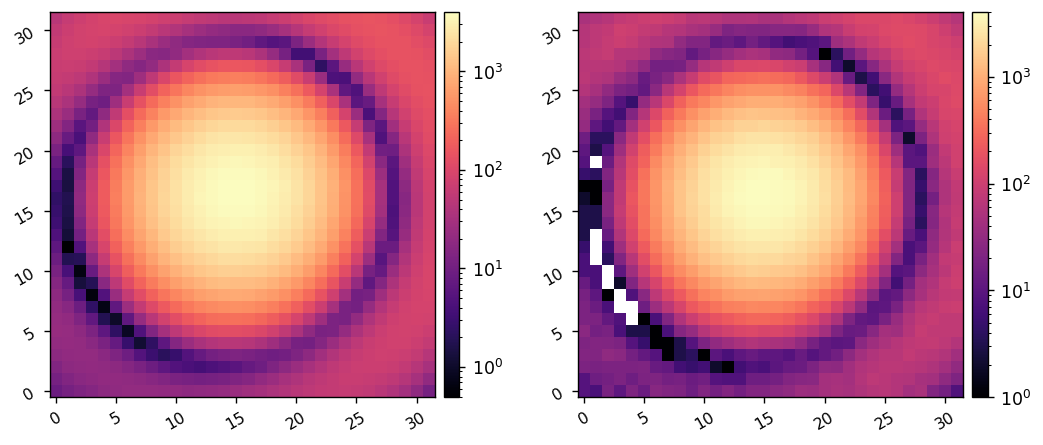

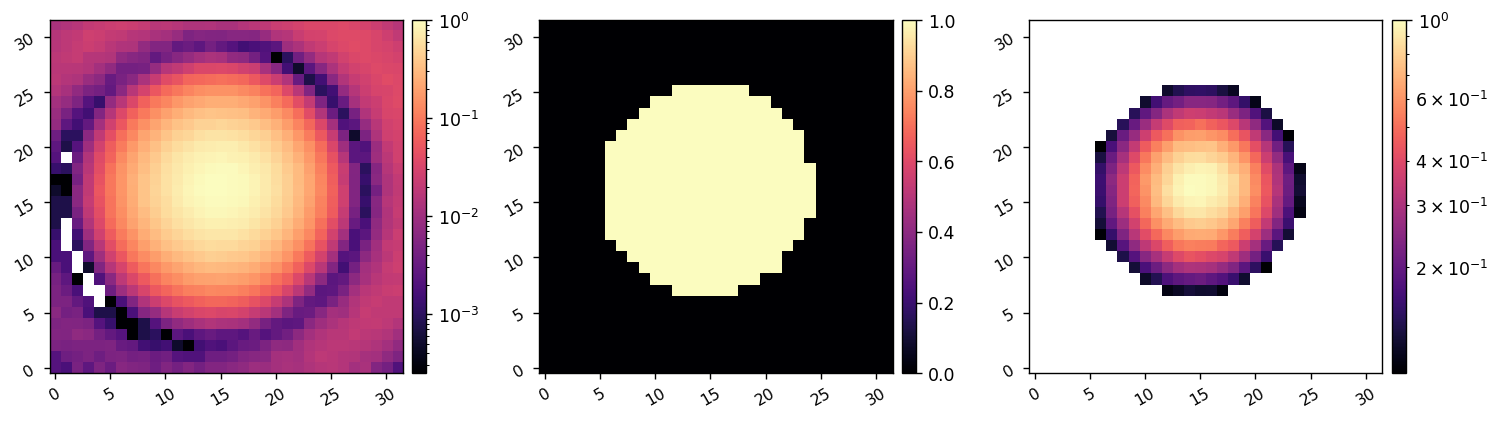

1.0 arcsec


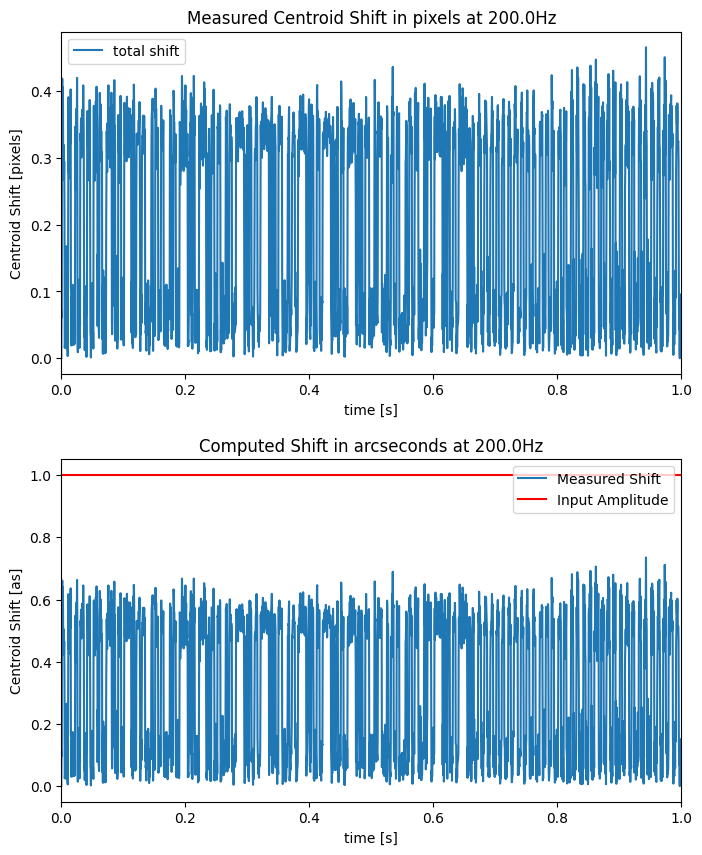

In [16]:
thresh = 0.1

ims = data['IMAGES']
N = ims.shape[0]
fps = data['FPS']
times = np.linspace(0, data['T_TOTAL'], N)
tmax = times.max()

mean_frame = np.mean(ims, axis=0)
imshow2(mean_frame, ims[0], lognorm=True)

shift_pix = []
cen_0 = utils.centroid(ims[0].astype(float), thresh=thresh, plot=True)
for i in range(N):
    cen = utils.centroid(ims[i].astype(float), thresh=thresh, plot=0)
    shift = cen - cen_0
    shift_pix.append(shift)
shift_pix = np.array(shift_pix)

total_shift = np.sqrt( np.sum( np.square(shift_pix), axis=1) )

shift_as = shift_pix * pxscl_lamD * as_per_lamD # pixels * (lamD/pixel) * (as/lamD)
shift_as = np.sqrt( np.sum( np.square(shift_as), axis=1) )

print(data['AMP'])

fig = plt.figure(figsize=(8,10))
plt.subplot(211)
# plt.plot(times, shift_pix[:,0], label='x-coordinate')
# plt.plot(times, shift_pix[:,1], label='y-coordinate')
plt.plot(times, total_shift, label='total shift')
plt.title(f'Measured Centroid Shift in pixels at {data["FREQ"]:.1f}Hz')
plt.ylabel('Centroid Shift [pixels]')
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
plt.legend()

plt.subplot(212)
plt.plot(times, shift_as, label='Measured Shift')
plt.axhline(y=data['AMP'].to_value(u.arcsec), color='r', linestyle='-', label='Input Amplitude')
plt.title(f'Computed Shift in arcseconds at {data["FREQ"]:.1f}Hz')
plt.ylabel('Centroid Shift [as]')
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
plt.legend()

plt.subplots_adjust(hspace=0.25)
plt.show()

200.0


(0.0, 1.0)

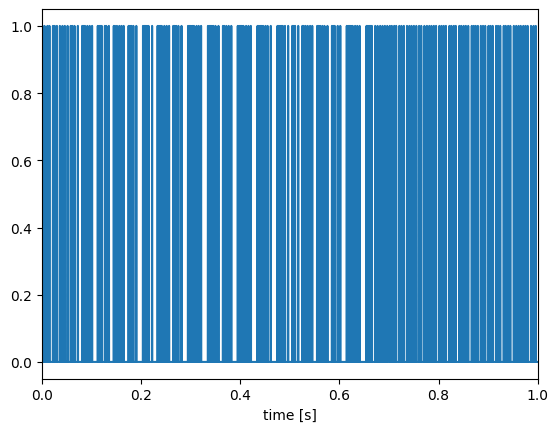

In [17]:
shift_thresh = shift_as.max()/2.2
# shift_thresh = 0.1*u.arcsec

shift_ud = shift_as>shift_thresh
steps = np.abs(shift_ud[1:].astype(float) - shift_ud[:-1].astype(float))
step_count = np.sum(steps)
print(step_count/tmax)

# plt.plot(times, shift_ud,)
# plt.xlabel('time [s]')
# plt.xlim([0,times.max()])
# plt.xlim([0, 1])

plt.plot(times[1:], steps,)
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])


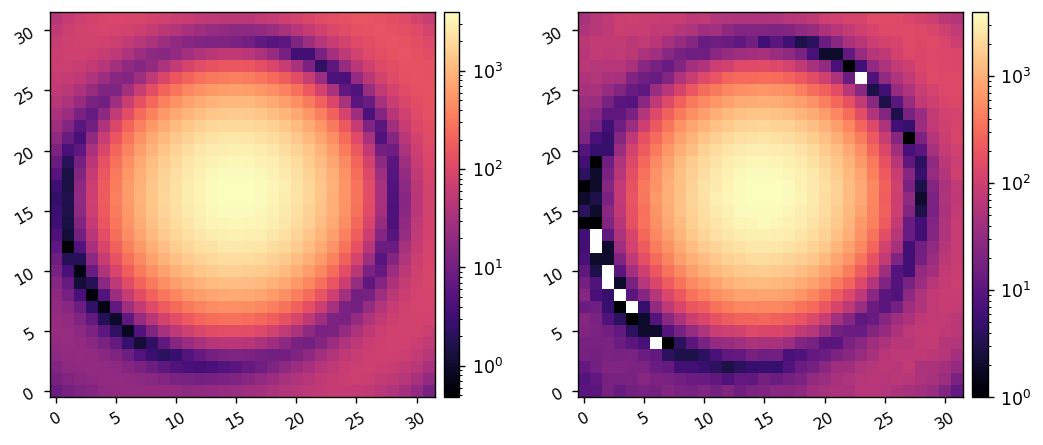

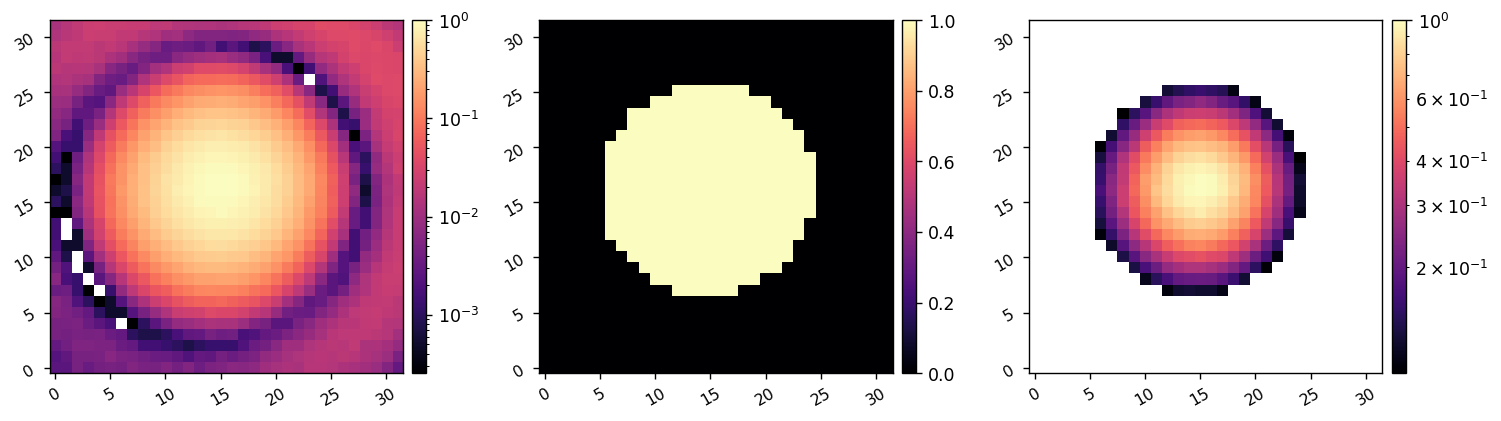

1.0 arcsec


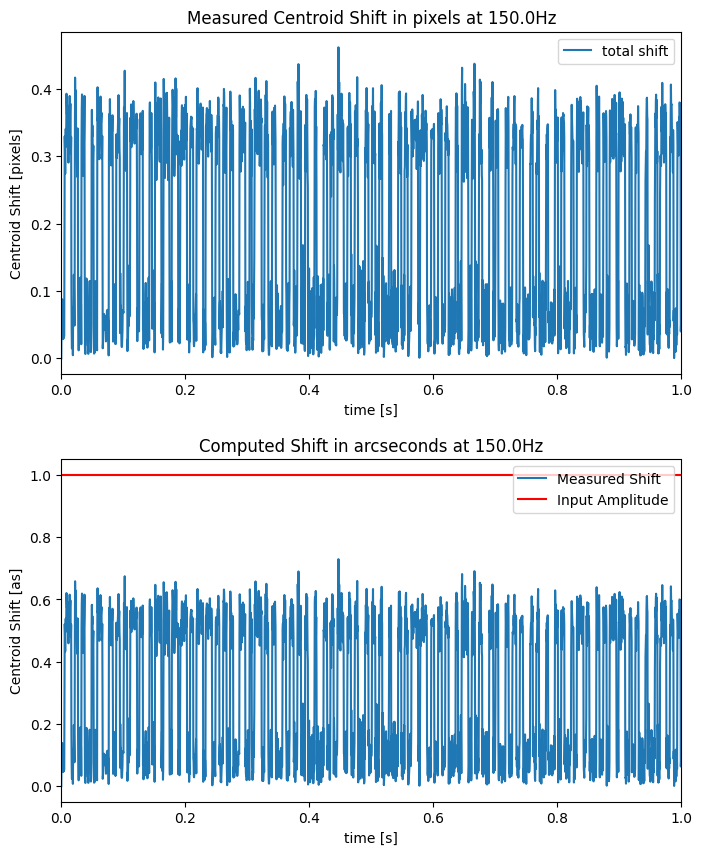

In [8]:
thresh = 0.1

ims = data['IMAGES']
N = ims.shape[0]
fps = data['FPS']
times = np.linspace(0, data['T_TOTAL'], N)
tmax = times.max()

mean_frame = np.mean(ims, axis=0)
imshow2(mean_frame, ims[0], lognorm=True)

shift_pix = []
cen_0 = utils.centroid(ims[0].astype(float), thresh=thresh, plot=True)
for i in range(N):
    cen = utils.centroid(ims[i].astype(float), thresh=thresh, plot=0)
    shift = cen - cen_0
    shift_pix.append(shift)
shift_pix = np.array(shift_pix)

total_shift = np.sqrt( np.sum( np.square(shift_pix), axis=1) )

shift_as = shift_pix * pxscl_lamD * as_per_lamD # pixels * (lamD/pixel) * (as/lamD)
shift_as = np.sqrt( np.sum( np.square(shift_as), axis=1) )

print(data['AMP'])

fig = plt.figure(figsize=(8,10))
plt.subplot(211)
# plt.plot(times, shift_pix[:,0], label='x-coordinate')
# plt.plot(times, shift_pix[:,1], label='y-coordinate')
plt.plot(times, total_shift, label='total shift')
plt.title(f'Measured Centroid Shift in pixels at {data["FREQ"]:.1f}Hz')
plt.ylabel('Centroid Shift [pixels]')
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
plt.legend()

plt.subplot(212)
plt.plot(times, shift_as, label='Measured Shift')
plt.axhline(y=data['AMP'].to_value(u.arcsec), color='r', linestyle='-', label='Input Amplitude')
plt.title(f'Computed Shift in arcseconds at {data["FREQ"]:.1f}Hz')
plt.ylabel('Centroid Shift [as]')
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
plt.legend()

plt.subplots_adjust(hspace=0.25)
plt.show()

150.0


(0.0, 1.0)

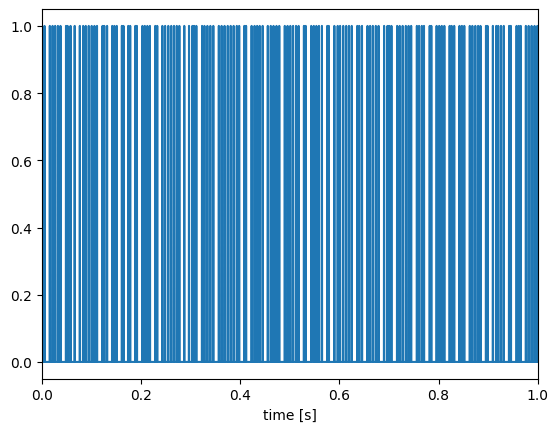

In [13]:
shift_thresh = shift_as.max()/2.2
# shift_thresh = 0.1*u.arcsec

shift_ud = shift_as>shift_thresh
steps = np.abs(shift_ud[1:].astype(float) - shift_ud[:-1].astype(float))
step_count = np.sum(steps)
print(step_count/tmax)

# plt.plot(times, shift_ud,)
# plt.xlabel('time [s]')
# plt.xlim([0,times.max()])
# plt.xlim([0, 1])

plt.plot(times[1:], steps,)
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])


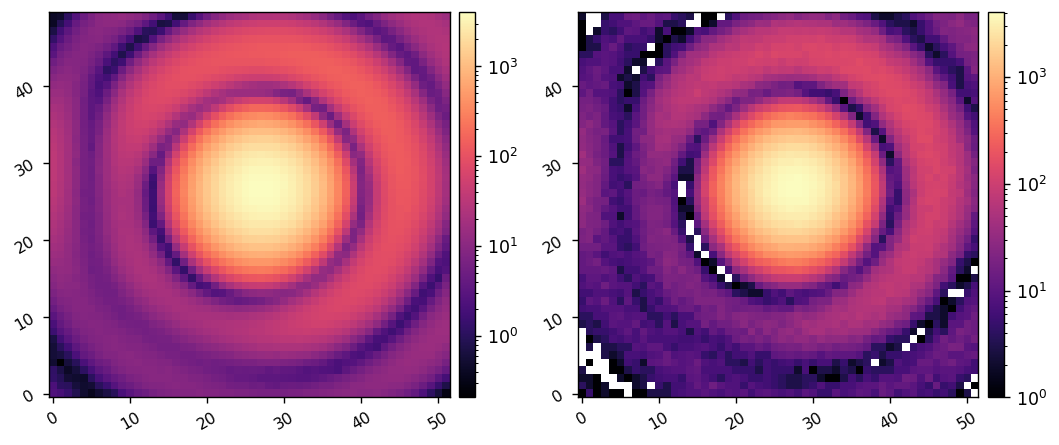

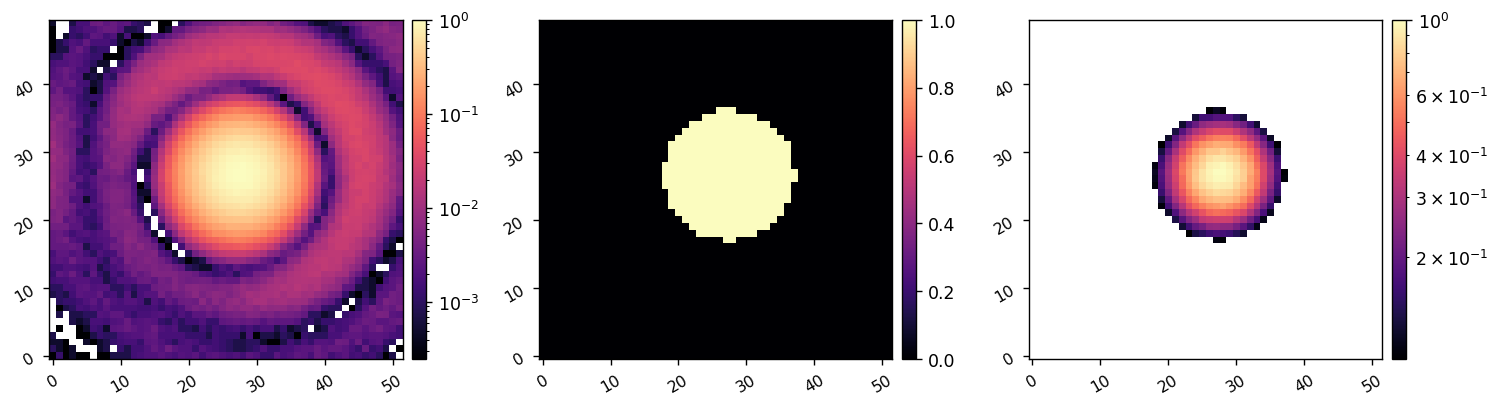

1.0 arcsec


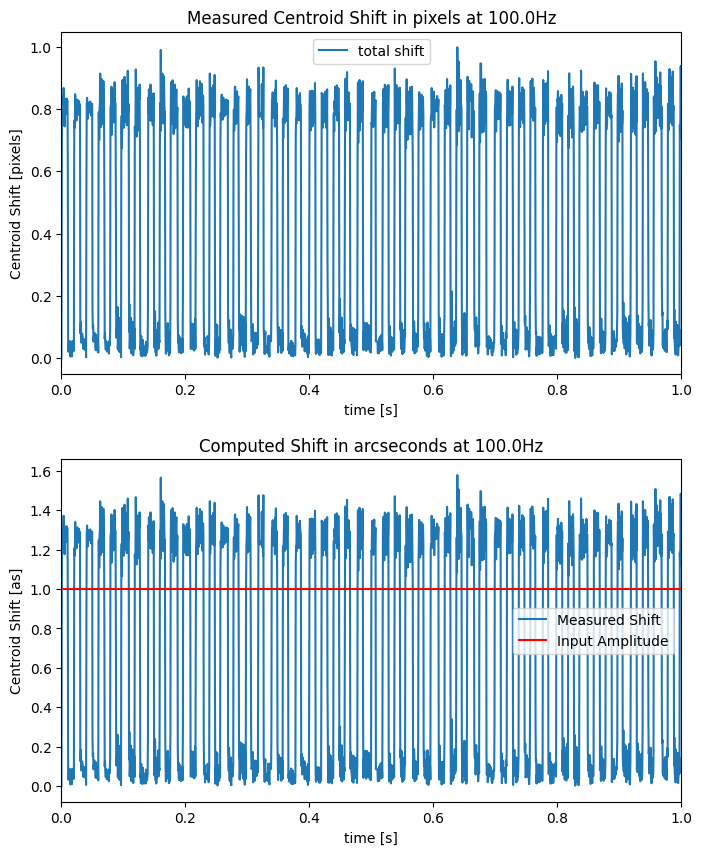

In [38]:
thresh = 0.1

ims = data['IMAGES']
N = ims.shape[0]
fps = data['FPS']
times = np.linspace(0, data['T_TOTAL'], N)
tmax = times.max()

mean_frame = np.mean(ims, axis=0)
imshow2(mean_frame, ims[0], lognorm=True)

shift_pix = []
cen_0 = utils.centroid(ims[0].astype(float), thresh=thresh, plot=True)
for i in range(N):
    cen = utils.centroid(ims[i].astype(float), thresh=thresh, plot=0)
    shift = cen - cen_0
    shift_pix.append(shift)
shift_pix = np.array(shift_pix)

total_shift = np.sqrt( np.sum( np.square(shift_pix), axis=1) )

shift_as = shift_pix * pxscl_lamD * as_per_lamD # pixels * (lamD/pixel) * (as/lamD)
shift_as = np.sqrt( np.sum( np.square(shift_as), axis=1) )

print(data['AMP'])

fig = plt.figure(figsize=(8,10))
plt.subplot(211)
# plt.plot(times, shift_pix[:,0], label='x-coordinate')
# plt.plot(times, shift_pix[:,1], label='y-coordinate')
plt.plot(times, total_shift, label='total shift')
plt.title(f'Measured Centroid Shift in pixels at {data["FREQ"]:.1f}Hz')
plt.ylabel('Centroid Shift [pixels]')
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
plt.legend()

plt.subplot(212)
plt.plot(times, shift_as, label='Measured Shift')
plt.axhline(y=data['AMP'].to_value(u.arcsec), color='r', linestyle='-', label='Input Amplitude')
plt.title(f'Computed Shift in arcseconds at {data["FREQ"]:.1f}Hz')
plt.ylabel('Centroid Shift [as]')
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
plt.legend()

plt.subplots_adjust(hspace=0.25)
plt.show()

101.0


(0.0, 1.0)

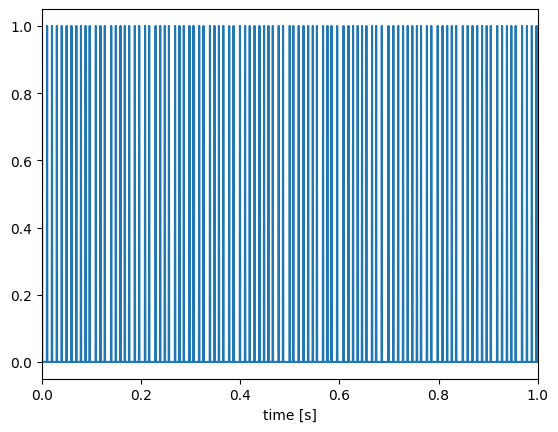

In [36]:
shift_thresh = 0.5*u.arcsec
# shift_thresh = 0.1*u.arcsec

shift_ud = shift_as>shift_thresh
steps = np.abs(shift_ud[1:].astype(float) - shift_ud[:-1].astype(float))
step_count = np.sum(steps)
print(step_count/tmax)

# plt.plot(times, shift_ud,)
# plt.xlabel('time [s]')
# plt.xlim([0,times.max()])
# plt.xlim([0, 1])

plt.plot(times[1:], steps,)
plt.xlabel('time [s]')
plt.xlim([0,tmax])
# plt.xlim([0, 1])
